In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
module_path = os.path.abspath(os.path.join('../../../../../'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [3]:
from machines.predictions.svr_prediction import SVR_Prediction
from machines.enums import SvrKernelEnum
from preprocesses.preprocess import Preprocess
from preprocesses.enums import TransformEnum, TypeFileEnum, StandardScaleEnum
from metrics.error_metric import ErrorMetric
from metrics.enums import MetricEnum, PlotLegends

Read the file and prepare data for SVR

In [4]:
file_csv = '../../../../../../data/phen/original/obregon_phenotypic_original_151617.csv'
print(os.getcwd())
svr = SVR_Prediction(kernel=SvrKernelEnum.SIGMOID)
preprocessing =  Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.PCA,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

/phen/app/notebooks/phen/pca/phenotypic/svr


Launched SVR

In [5]:
x_train, y_train = preprocessing.get_train()
svr.training(x_train=x_train, y_train=y_train)

In [6]:
x_test, y_test = preprocessing.get_test()
y_predicted = svr.prediction(x_test=x_test)

Get metrics

In [7]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 90.47583791223818
R2 -> 0.1501346539695113
MAPE -> 0.12548390877237112


{'d2_absolute_error_score': 0.11117934058230505,
 'd2_pinball_score': 0.11117934058230505,
 'd2_tweedie_score': 0.1501346539695112,
 'explained_variance_score': 0.22635188550363738,
 'max_error': 375.1267624949694,
 'mean_absolute_error': 62.019688967508706,
 'mean_absolute_percentage_error': 0.12548390877237112,
 'mean_gamma_deviance': 0.027398663423381903,
 'mean_poisson_deviance': 14.747433076682077,
 'mean_squared_error': 8185.877245921596,
 'mean_squared_log_error': 0.03177024391192987,
 'median_absolute_error': 40.1594190402854,
 'r2_score': 0.1501346539695113,
 'root_mean_squared_error': 90.47583791223818,
 'root_mean_squared_log_error': 0.1782420935467542}

Plots:

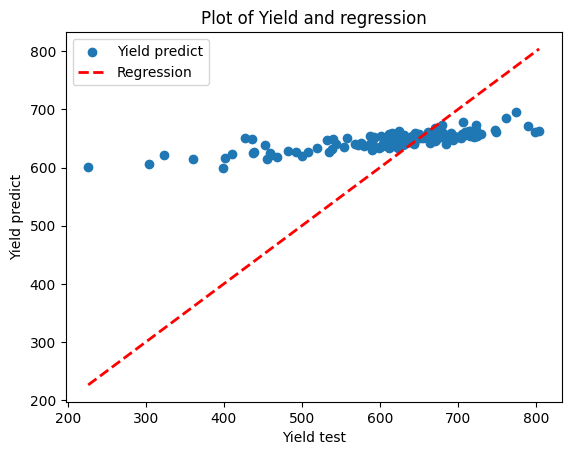

In [8]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = "Plot of Yield and regression"
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)


Plot $r^2$

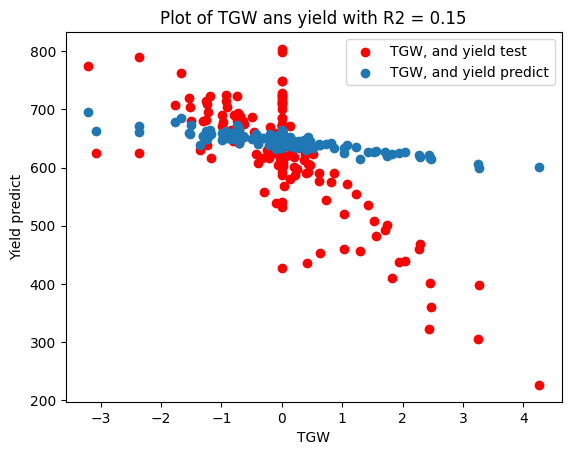

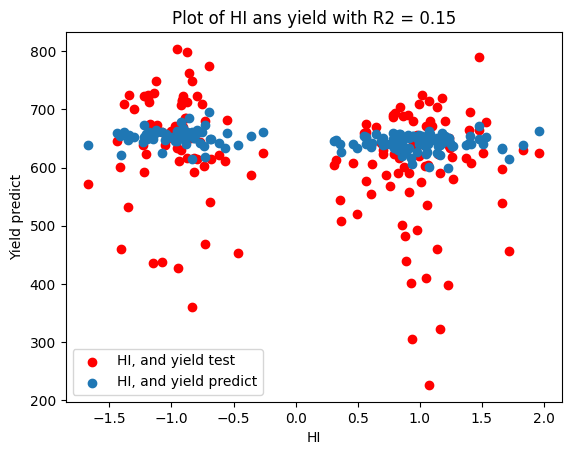

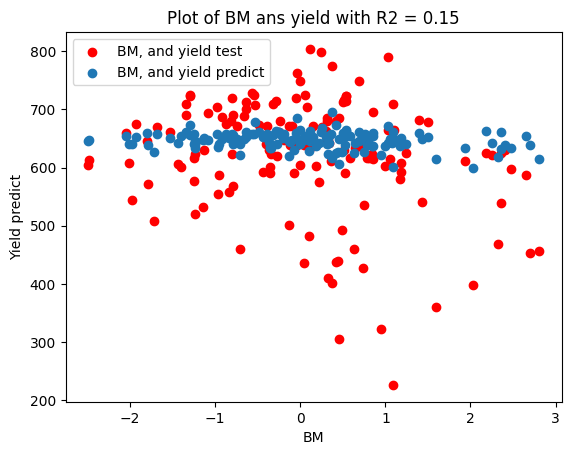

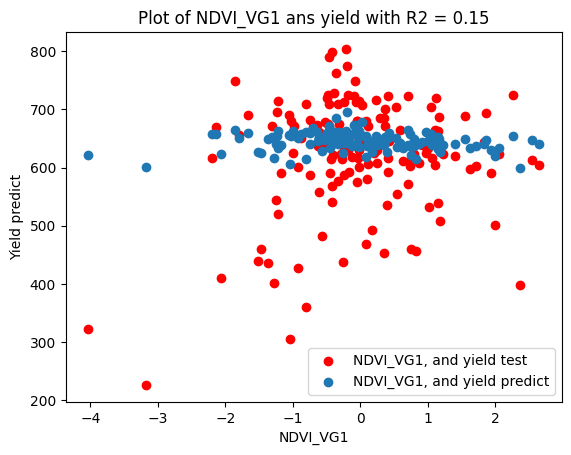

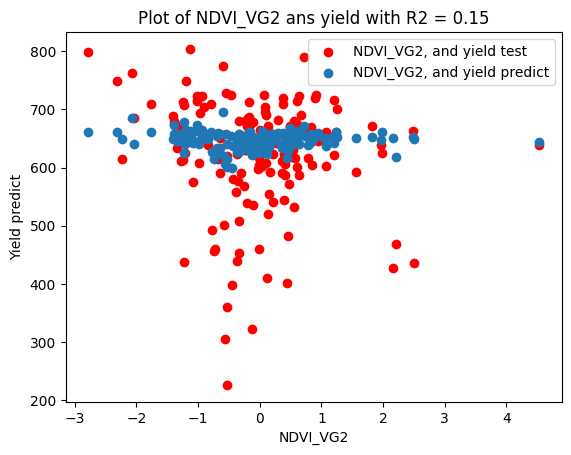

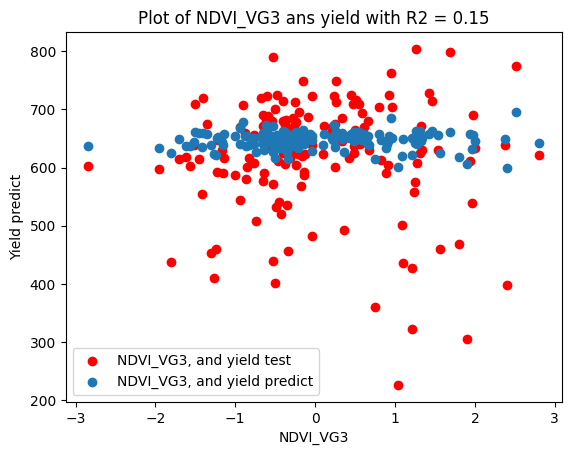

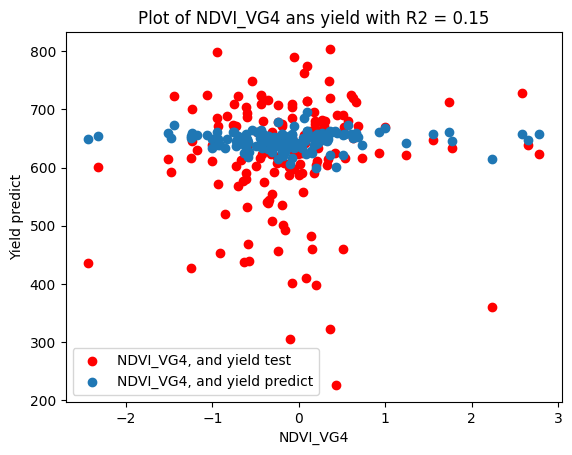

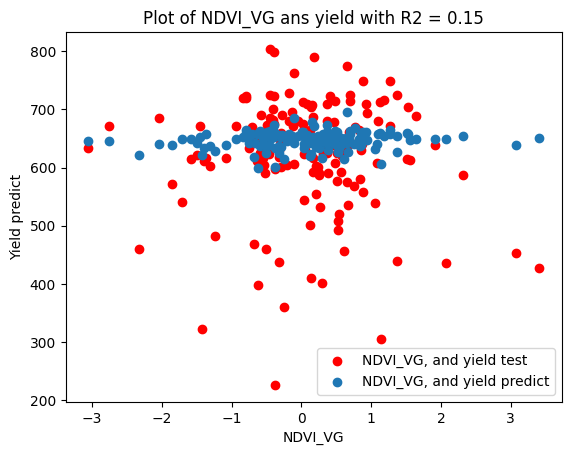

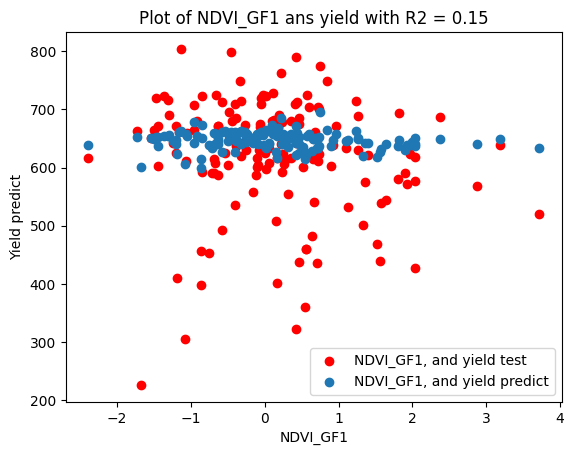

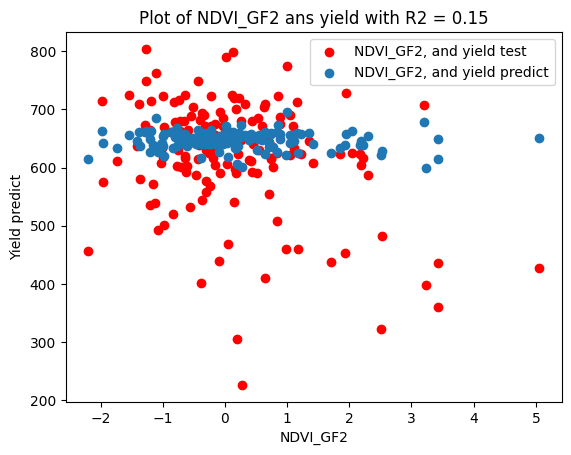

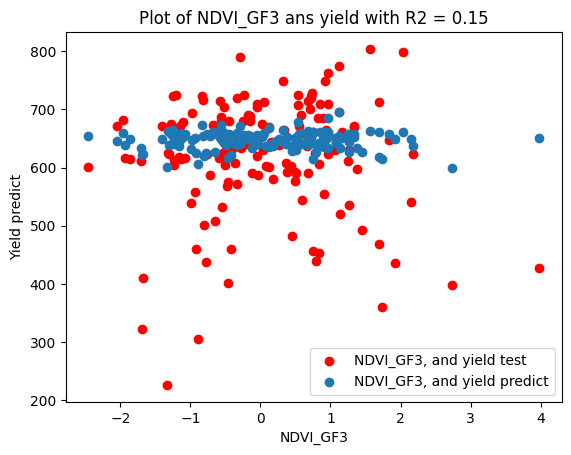

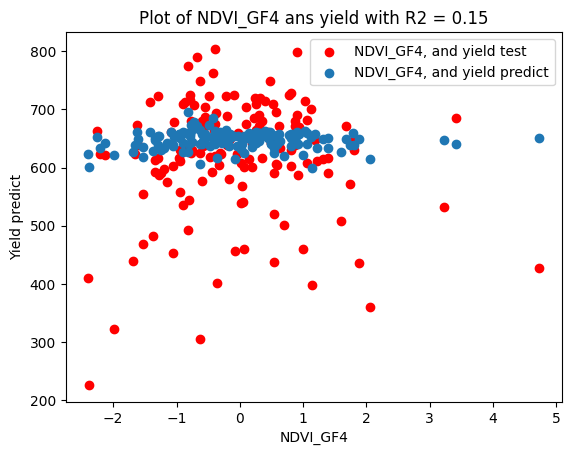

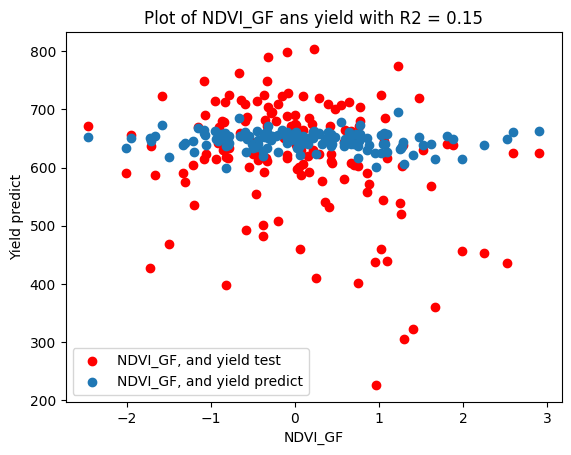

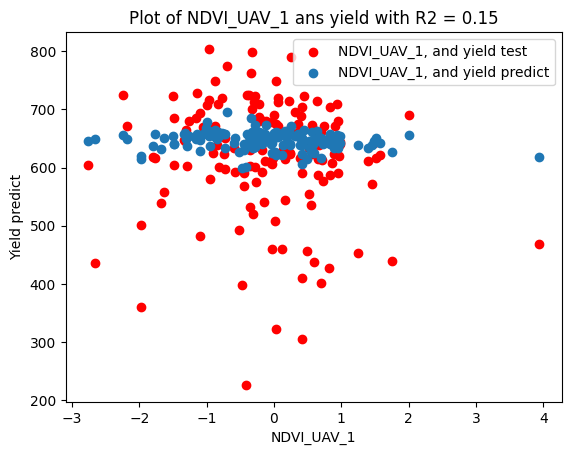

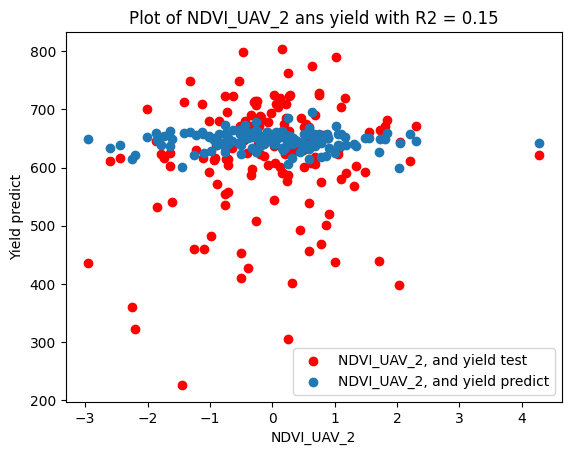

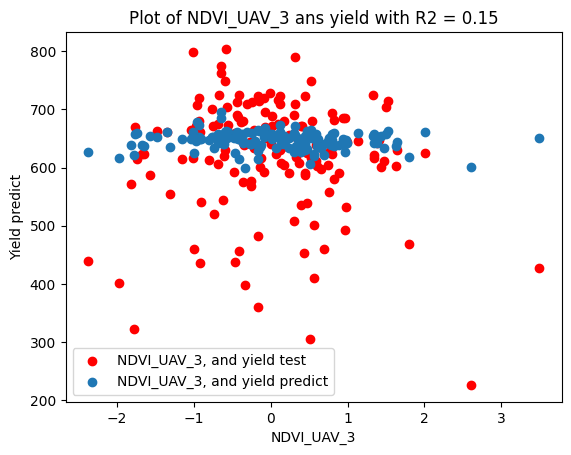

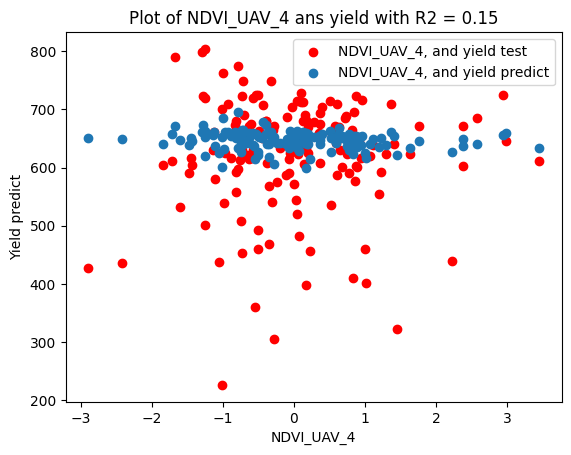

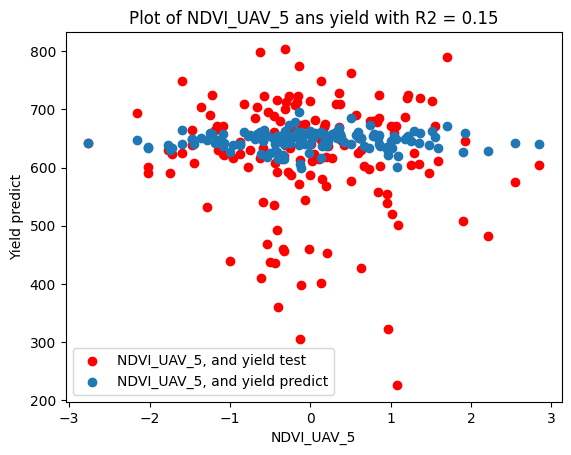

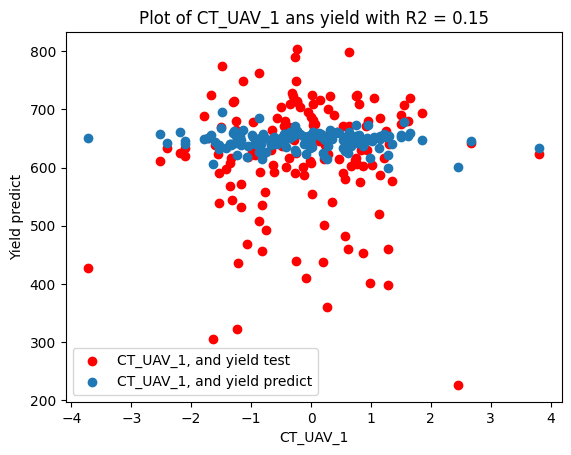

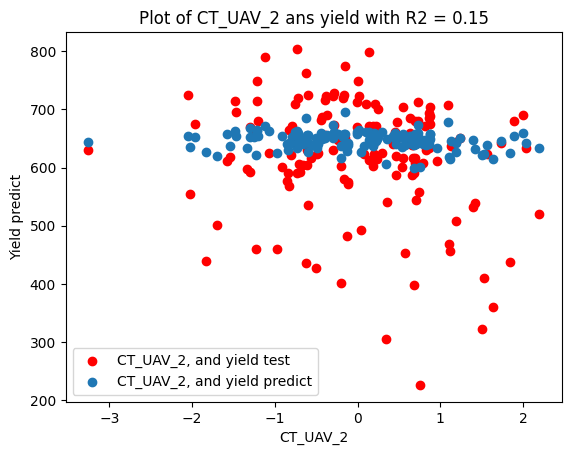

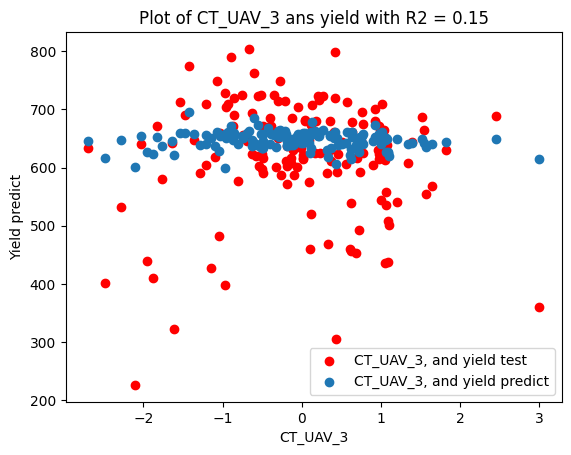

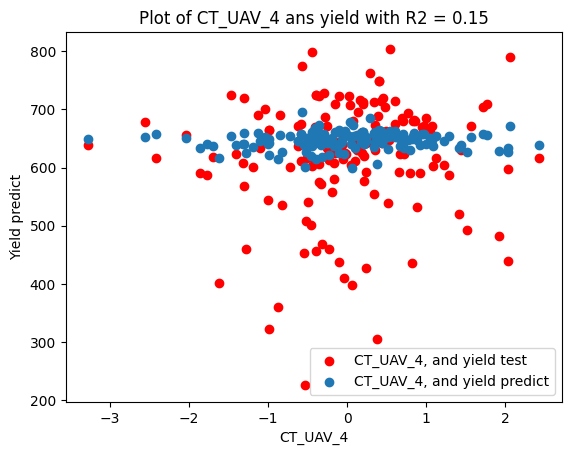

In [9]:
legend = PlotLegends()
legend.first_plot_label = "{variable}, and yield test"
legend.second_plot_label = "{variable}, and yield predict"
legend.title = "Plot of {variable} ans yield with R2 = {r2:.2f}"
legend.x_label = "{variable}"
legend.y_label = "Yield predict"
features = preprocessing.get_name_features()
metric.plot_r2_predicted(legend=legend, features=features)

Get the predict that are more bigger that .05

In [10]:
metric.list_percentage_error_upper(pivot=.04, sort = 'error')

[{'truth': 226.1118, 'predict': 601.2385624949694, 'error': 1.659032224302179},
 {'truth': 304.5419,
  'predict': 605.7418865882638,
  'error': 0.9890264248967509},
 {'truth': 322.9881,
  'predict': 620.9619899565345,
  'error': 0.9225537719703435},
 {'truth': 360.0, 'predict': 615.4958638836893, 'error': 0.7097107330102479},
 {'truth': 400.8056, 'predict': 616.6682320063704, 'error': 0.538571896216945},
 {'truth': 427.0, 'predict': 651.0157438209235, 'error': 0.5246270347094227},
 {'truth': 409.865, 'predict': 623.5625840633871, 'error': 0.5213852953128155},
 {'truth': 398.2896,
  'predict': 598.5655781968562,
  'error': 0.5028400897157651},
 {'truth': 436.0, 'predict': 648.9840207351003, 'error': 0.48849546040160624},
 {'truth': 437.0, 'predict': 625.0198661034356, 'error': 0.4302514098476786},
 {'truth': 438.9351,
  'predict': 625.9172970623097,
  'error': 0.42599053268309983},
 {'truth': 453.0, 'predict': 638.1591660130307, 'error': 0.40873988082346735},
 {'truth': 459.2263, 'predi